# Previsão de Churn em Telecom

### Um projeto de Machine Learning aplicado à retenção de clientes

Este projeto tem como objetivo analisar o comportamento de clientes de uma empresa de telecomunicações e desenvolver um modelo capaz de identificar clientes com maior probabilidade de cancelamento.

A ideia é ir além da previsão: entender quais características estão mais relacionadas ao churn e transformar essas informações em apoio para estratégias de retenção.

## 1. Contexto do problema

A perda de clientes, conhecida como **churn**, é um dos principais desafios para empresas de serviços recorrentes, como as operadoras de telecomunicações.

Conquistar um novo cliente normalmente exige investimento em aquisição, enquanto a retenção de um cliente existente pode representar uma oportunidade de preservar receita e relacionamento.

Neste projeto, o problema pode ser resumido em uma pergunta:

**Quais clientes apresentam maior probabilidade de cancelar o serviço?**

Para responder a essa pergunta, serão analisados dados sobre perfil, serviços contratados, tipo de contrato, tempo de permanência e informações de cobrança.

In [35]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
%config InlineBackend.figure_format = "svg"
plt.rcParams["font.family"] = "sans-serif"
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix)

## 2. Carregando os dados

O conjunto de dados utilizado reúne informações de clientes de uma empresa de telecomunicações.

Entre as informações disponíveis estão características do cliente, serviços contratados, tipo de contrato, tempo de permanência e valores de cobrança.

A variável **Churn** será utilizada como variável-alvo do modelo, indicando se o cliente permaneceu ou cancelou o serviço.

In [36]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

print('Quantidade de linhas:', df.shape[0])
print('Quantidade de colunas:', df.shape[1])

df.head()

Quantidade de linhas: 7043
Quantidade de colunas: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## 3. Conhecendo as variáveis

Antes de construir o modelo, é importante entender o que cada informação representa e por que ela pode ser relevante para a análise.

Algumas das principais variáveis são:

**tenure** — representa há quantos meses o cliente está na empresa. Essa informação permite observar se o tempo de relacionamento está associado ao cancelamento.

**Contract** — indica o tipo de contrato do cliente. Contratos com diferentes níveis de compromisso podem apresentar comportamentos distintos em relação ao churn.

**MonthlyCharges** — representa o valor cobrado mensalmente. Essa variável ajuda a analisar a relação entre o custo recorrente e o cancelamento.

**TotalCharges** — representa o total acumulado de cobranças do cliente durante o período analisado.

**PaymentMethod** — indica a forma utilizada pelo cliente para realizar os pagamentos.

**InternetService** — identifica o tipo de serviço de internet contratado.

**Churn** — indica se o cliente cancelou o serviço. Essa será a variável que o modelo tentará prever.

In [38]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


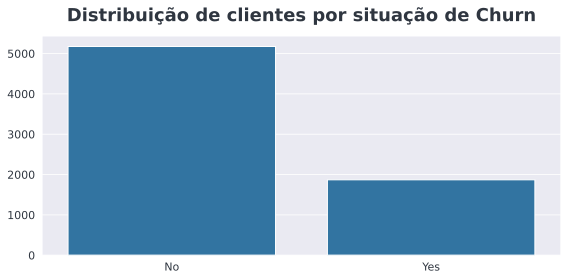

In [39]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.set_style('darkgrid')
sns.countplot(data=df, x='Churn', ax=ax)

ax.set_title('Distribuição de clientes por situação de Churn', fontsize=18, fontweight='semibold', pad=15, color = '#2F3640')

ax.set_xlabel('')
ax.set_ylabel('')

ax.tick_params(axis='x', labelsize=11, colors = '#2F3640')
ax.tick_params(axis='y', labelsize=11, colors = '#2F3640')

plt.tight_layout()

# plt.savefig(
# 'distribuicao-churn.png',
# dpi=150,
# bbox_inches='tight'
# )

### Primeira observação

A distribuição mostra que a quantidade de clientes que permaneceu na empresa é maior do que a quantidade de clientes que cancelou.

Isso significa que as classes não estão perfeitamente equilibradas.

Por esse motivo, a **acurácia não deve ser analisada sozinha**. Em um problema de churn, também é importante observar métricas como **recall, precisão, F1-score e ROC-AUC**.

O recall merece atenção especial porque representa a capacidade do modelo de identificar os clientes que realmente cancelaram.

## 4. Tratamento inicial dos dados

Antes da modelagem, algumas informações precisam ser preparadas.

A coluna `customerID` será removida porque funciona apenas como identificador do cliente e não possui utilidade direta para a previsão.

A coluna `TotalCharges` será convertida para formato numérico. Alguns registros podem apresentar valores ausentes após essa conversão.

O preenchimento desses valores será realizado posteriormente dentro do pipeline de pré-processamento. Dessa forma, as informações utilizadas para preencher os dados do conjunto de teste não influenciam o treinamento do modelo.

In [40]:
df = df.drop(columns=['customerID'], errors='ignore')

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})

df.isna().sum().sort_values(ascending=False).head(10)

,0
TotalCharges,11
gender,0
Partner,0
SeniorCitizen,0
Dependents,0
tenure,0
MultipleLines,0
PhoneService,0
OnlineSecurity,0
OnlineBackup,0


## 5. Análise exploratória

Antes de treinar o modelo, algumas relações entre as variáveis e o churn serão analisadas.

O objetivo desta etapa é identificar padrões que possam ajudar a interpretar o comportamento dos clientes.

Essas análises mostram **associações observadas nos dados**. Elas não significam, por si só, que uma variável seja a causa do cancelamento.

### Churn por tipo de contrato

O tipo de contrato pode estar relacionado ao nível de compromisso do cliente com a empresa.

A seguir, será calculada a taxa de churn para cada tipo de contrato, permitindo comparar quais grupos apresentam maior proporção de cancelamentos.

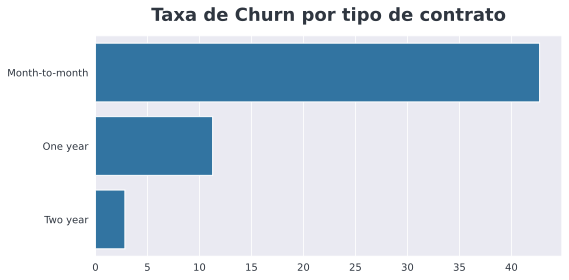

In [41]:
taxa_contrato = (df.groupby('Contract')['Churn'].mean().sort_values(ascending=False).mul(100))

fig, ax = plt.subplots(figsize=(8, 4))

sns.barplot(x=taxa_contrato.values, y=taxa_contrato.index, ax=ax)

ax.set_title('Taxa de Churn por tipo de contrato', fontsize=18, fontweight='semibold', color = '#2F3640', pad=15)

ax.set_xlabel('')

ax.set_ylabel('')

ax.tick_params(axis='both', labelsize=10, colors = '#2F3640')

plt.tight_layout()

plt.savefig('churn-por-contrato.png', dpi=150, bbox_inches='tight')

## 6. Preparação para a modelagem

Após a análise exploratória, os dados serão preparados para o treinamento dos modelos.

A variável `Churn` será utilizada como variável-alvo (`y`), enquanto as demais características formarão o conjunto de variáveis preditoras (`X`).

Para avaliar o desempenho dos modelos de forma mais confiável, os dados serão divididos em três conjuntos:

* **Treino (60%)** — utilizado para ajustar os modelos.
* **Validação (20%)** — utilizado para comparar decisões de modelagem e definir o threshold.
* **Teste (20%)** — mantido separado para a avaliação final do desempenho.

A divisão será realizada de forma estratificada pela variável `Churn`, preservando aproximadamente a mesma proporção de clientes que cancelaram e permaneceram em cada conjunto.

Essa separação permite utilizar o conjunto de validação para tomar decisões sem utilizar antecipadamente as informações do conjunto de teste.

In [42]:
from sklearn.linear_model import LogisticRegression

In [43]:
X = df.drop(columns='Churn')
y = df['Churn']

print('Variáveis preditoras:', X.shape[1])
print('Quantidade de registros:', X.shape[0])

Variáveis preditoras: 19
Quantidade de registros: 7043


In [44]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.40, random_state=42, stratify=y)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print('Treino:', X_train.shape)
print('Validação:', X_val.shape)
print('Teste:', X_test.shape)

print('\nProporção de churn:')
print(f'Treino: {y_train.mean():.2%}')
print(f'Validação: {y_val.mean():.2%}')
print(f'Teste: {y_test.mean():.2%}')

Treino: (4225, 19)
Validação: (1409, 19)
Teste: (1409, 19)

Proporção de churn:
Treino: 26.53%
Validação: 26.54%
Teste: 26.54%


## 7. Pipeline de pré-processamento

As variáveis numéricas e categóricas exigem tratamentos diferentes.

Para evitar data leakage, todas as transformações serão ajustadas apenas sobre os dados de treinamento utilizando `Pipeline` e `ColumnTransformer`.

As variáveis numéricas terão valores ausentes preenchidos pela mediana.

As variáveis categóricas terão valores ausentes preenchidos pela categoria mais frequente e serão transformadas utilizando One-Hot Encoding.

In [45]:
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

categorical_features = X_train.select_dtypes(include=['object']).columns.tolist()

print('Variáveis numéricas:')
print(numeric_features)

print('\nVariáveis categóricas:')
print(categorical_features)

Variáveis numéricas:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Variáveis categóricas:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [46]:
numeric_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='median'))])

categorical_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore'))])

preprocessor = ColumnTransformer(transformers=[('num', numeric_transformer, numeric_features), ('cat', categorical_transformer, categorical_features)])

## 8. Logistic Regression — modelo baseline

A Logistic Regression será utilizada como modelo de referência.

O objetivo é estabelecer um baseline antes da utilização de um modelo mais complexo.

O desempenho será avaliado tanto nos dados de treinamento quanto nos dados de teste para observar a capacidade de generalização do modelo.

In [47]:
logistic_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', LogisticRegression(max_iter=1000, random_state=42))])

logistic_pipeline.fit(X_train, y_train)

print('Logistic Regression treinada com sucesso.')

Logistic Regression treinada com sucesso.


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## 9. Random Forest Classifier

O Random Forest será utilizado como segundo modelo.

Ao combinar várias árvores de decisão, o algoritmo consegue representar relações mais complexas entre as características dos clientes.

Seu desempenho será comparado ao baseline para avaliar se o aumento de complexidade produz ganhos relevantes para o problema de churn.

In [48]:
random_forest_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1))])

random_forest_pipeline.fit(X_train, y_train)

print('Random Forest treinada com sucesso.')

Random Forest treinada com sucesso.


In [49]:
def avaliar_modelo(nome, modelo, X_train, y_train, X_test, y_test):

    pred_train = modelo.predict(X_train)
    pred_test = modelo.predict(X_test)
    prob_test = modelo.predict_proba(X_test)[:, 1]

    resultados = {
        'Modelo': nome,
        'Accuracy Treino': accuracy_score(y_train, pred_train),
        'Accuracy Teste': accuracy_score(y_test, pred_test),
        'Precision': precision_score(y_test, pred_test),
        'Recall': recall_score(y_test, pred_test),
        'F1-score': f1_score(y_test, pred_test),
        'ROC-AUC': roc_auc_score(y_test, prob_test)
    }

    return resultados

In [50]:
resultado_logistic = avaliar_modelo('Logistic Regression', logistic_pipeline, X_train, y_train, X_test, y_test)
resultado_rf = avaliar_modelo('Random Forest', random_forest_pipeline, X_train, y_train, X_test, y_test)
resultados = pd.DataFrame([resultado_logistic, resultado_rf])
resultados

,Modelo,Accuracy Treino,Accuracy Teste,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.804497,0.788502,0.619497,0.526738,0.569364,0.832682
1,Random Forest,0.998343,0.778566,0.607639,0.467914,0.528701,0.806265


In [51]:
resultados_formatados = resultados.copy()

metricas = ['Accuracy Treino', 'Accuracy Teste', 'Precision', 'Recall', 'F1-score', 'ROC-AUC']

for coluna in metricas: resultados_formatados[coluna] = (resultados_formatados[coluna] * 100).round(2)

resultados_formatados

,Modelo,Accuracy Treino,Accuracy Teste,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,80.45,78.85,61.95,52.67,56.94,83.27
1,Random Forest,99.83,77.86,60.76,46.79,52.87,80.63


## 10. Comparação dos modelos

A comparação entre Logistic Regression e Random Forest permite avaliar se o aumento de complexidade do modelo resulta em ganhos relevantes.

Além da acurácia, são consideradas Precision, Recall, F1-score e ROC-AUC.

Como o objetivo do projeto envolve identificar clientes com risco de cancelamento, o **Recall recebe atenção especial**, pois representa a proporção de clientes que realmente cancelaram e foram identificados pelo modelo.

Também é importante comparar o desempenho entre treinamento e teste. Uma diferença muito elevada entre os dois conjuntos pode indicar overfitting.

In [52]:
melhor_indice = resultados['Recall'].idxmax()

melhor_nome = resultados.loc[melhor_indice, 'Modelo']

if melhor_nome == 'Logistic Regression': melhor_modelo = logistic_pipeline
else: melhor_modelo = random_forest_pipeline

print('Modelo selecionado para análise:', melhor_nome)

Modelo selecionado para análise: Logistic Regression


## 11. Matriz de confusão

A matriz de confusão permite observar não apenas quantas previsões foram corretas, mas também quais tipos de erro foram cometidos.

No contexto deste projeto, os falsos negativos merecem atenção especial, pois representam clientes que efetivamente cancelaram, mas não foram identificados pelo modelo como clientes de risco.

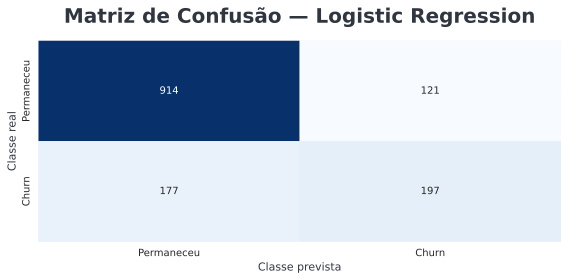

In [53]:
y_pred = melhor_modelo.predict(X_test)

matriz = confusion_matrix(
    y_test,
    y_pred
)

fig, ax = plt.subplots(
    figsize=(8, 4),
    dpi=150
)

sns.heatmap(
    matriz,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    ax=ax
)

ax.set_title(
    f'Matriz de Confusão — {melhor_nome}',
    fontsize=20,
    fontweight='semibold', color = '#2F3640',
    pad=18
)

ax.set_xlabel(
    'Classe prevista', color = '#2F3640', fontsize = 11
)

ax.set_ylabel(
    'Classe real', color = '#2F3640', fontsize = 11
)

ax.set_xticklabels([
    'Permaneceu',
    'Churn'
])

ax.set_yticklabels([
    'Permaneceu',
    'Churn'
])

plt.tight_layout()

plt.savefig(
    'matriz-confusao.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

## 12. Análise do threshold

Por padrão, modelos de classificação normalmente utilizam probabilidade de 0,50 como limite para definir uma classe positiva.

No problema de churn, entretanto, falsos negativos podem representar oportunidades de retenção perdidas.

Por esse motivo, diferentes thresholds serão analisados no conjunto de validação.

Reduzir o threshold tende a aumentar o Recall, permitindo identificar mais clientes que realmente cancelam, mas também pode reduzir a Precision e aumentar a quantidade de falsos positivos.

A escolha do threshold representa, portanto, um equilíbrio entre desempenho estatístico e custo das ações de retenção.

In [54]:
prob_val = melhor_modelo.predict_proba(X_val)[:, 1]

thresholds = np.arange(0.20, 0.71, 0.05)

analise_threshold = []

for threshold in thresholds:
    pred_threshold = (prob_val >= threshold).astype(int)

    analise_threshold.append({
        'Threshold': threshold,
        'Precision': precision_score(
            y_val, pred_threshold, zero_division=0
        ),
        'Recall': recall_score(
            y_val, pred_threshold, zero_division=0
        ),
        'F1-score': f1_score(
            y_val, pred_threshold, zero_division=0
        )
    })

threshold_df = pd.DataFrame(analise_threshold)

threshold_df.round(3)

,Threshold,Precision,Recall,F1-score
0,0.20,0.468,0.890,0.613
1,0.25,0.506,0.845,0.633
2,0.30,0.534,0.794,0.639
3,0.35,0.566,0.746,0.644
4,0.40,0.594,0.701,0.643
5,0.45,0.629,0.647,0.638
6,0.50,0.703,0.596,0.645
7,0.55,0.725,0.500,0.592
8,0.60,0.752,0.406,0.528
9,0.65,0.763,0.283,0.413


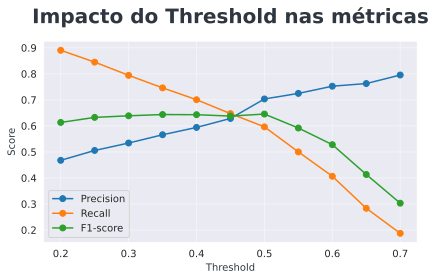

In [61]:
fig, ax = plt.subplots(figsize=(6, 4), dpi=150)
ax.plot(threshold_df['Threshold'], threshold_df['Precision'], marker='o', label='Precision')
ax.plot(threshold_df['Threshold'], threshold_df['Recall'], marker='o', label='Recall')
ax.plot(threshold_df['Threshold'], threshold_df['F1-score'], marker='o', label='F1-score')

ax.set_title('Impacto do Threshold nas métricas', fontsize=20, fontweight='semibold', color = '#2F3640', pad=18)

ax.set_xlabel('Threshold', color = '#2F3640')

ax.set_ylabel('Score', color = '#2F3640')

ax.legend()

ax.grid(alpha=0.50)

plt.tight_layout()


In [56]:
candidatos = threshold_df[threshold_df['Recall'] >= 0.70].copy()

if len(candidatos) > 0:
    melhor_threshold = candidatos.loc[
        candidatos['Precision'].idxmax(),
        'Threshold'
    ]
else:
    melhor_threshold = threshold_df.loc[
        threshold_df['F1-score'].idxmax(),
        'Threshold'
    ]

print(f'Threshold selecionado: {melhor_threshold:.2f}')

Threshold selecionado: 0.40


In [57]:
prob_test = melhor_modelo.predict_proba(X_test)[:, 1]
pred_final = (prob_test >= melhor_threshold).astype(int)

accuracy_final = accuracy_score(y_test, pred_final)

precision_final = precision_score(y_test, pred_final)

recall_final = recall_score(y_test, pred_final)

f1_final = f1_score(y_test, pred_final)

roc_auc_final = roc_auc_score(y_test, prob_test)

print(f'Modelo: {melhor_nome}')

print(f'Threshold: {melhor_threshold:.2f}')

print(f'Accuracy: {accuracy_final:.2%}')

print(f'Precision: {precision_final:.2%}')

print(f'Recall: {recall_final:.2%}')

print(f'F1-score: {f1_final:.2%}')

print(f'ROC-AUC: {roc_auc_final:.2%}')

Modelo: Logistic Regression
Threshold: 0.40
Accuracy: 77.64%
Precision: 56.72%
Recall: 66.58%
F1-score: 61.25%
ROC-AUC: 83.27%


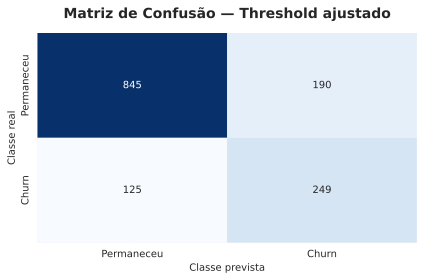

In [62]:
matriz_final = confusion_matrix(y_test, pred_final)

fig, ax = plt.subplots(figsize=(6, 4), dpi=150)

sns.heatmap(matriz_final, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)

ax.set_title('Matriz de Confusão — Threshold ajustado', fontsize=14, fontweight='semibold', pad=15)

ax.set_xlabel('Classe prevista')

ax.set_ylabel('Classe real')

ax.set_xticklabels(['Permaneceu', 'Churn'])

ax.set_yticklabels(['Permaneceu', 'Churn'])

plt.tight_layout()

plt.savefig('matriz-confusao-final.png', dpi=150, bbox_inches='tight')

plt.show()

## 13. Priorização de clientes

A probabilidade de churn não precisa ser utilizada apenas para classificar clientes entre cancelamento e permanência.

Ela também pode ajudar a criar uma fila de priorização para estratégias de retenção.

Neste exemplo, a probabilidade prevista de churn é combinada com o valor mensal pago pelo cliente.

O objetivo não é determinar automaticamente qual cliente deve receber uma oferta, mas criar uma informação adicional que possa apoiar a tomada de decisão.

In [59]:
clientes_prioridade = X_test.copy()

clientes_prioridade['Churn_real'] = y_test.values

clientes_prioridade['Probabilidade_Churn'] = prob_test

clientes_prioridade['Previsao_Churn'] = pred_final

clientes_prioridade['Score_Prioridade'] = (clientes_prioridade['Probabilidade_Churn'] * clientes_prioridade['MonthlyCharges'])

prioridade = (clientes_prioridade[clientes_prioridade['Previsao_Churn'] == 1].sort_values('Score_Prioridade', ascending=False))

prioridade[['tenure', 'Contract', 'MonthlyCharges', 'Probabilidade_Churn', 'Score_Prioridade']].head(15)

,tenure,Contract,MonthlyCharges,Probabilidade_Churn,Score_Prioridade
6894,3,Month-to-month,105.90,0.809807,85.758599
6365,7,Month-to-month,101.95,0.821542,83.756202
2797,3,Month-to-month,100.95,0.817219,82.498234
2294,12,Month-to-month,106.70,0.747973,79.808707
2448,14,Month-to-month,104.85,0.760231,79.710253
4800,1,Month-to-month,94.00,0.843292,79.269425
6866,1,Month-to-month,95.45,0.823560,78.608810
3727,3,Month-to-month,96.60,0.808739,78.124146
1568,11,Month-to-month,111.40,0.699235,77.894739
1148,2,Month-to-month,95.15,0.812710,77.329339


In [60]:
prioridade_visual = prioridade[['tenure', 'Contract', 'MonthlyCharges', 'Probabilidade_Churn', 'Score_Prioridade']].head(15).copy()

prioridade_visual['Probabilidade_Churn'] = (prioridade_visual['Probabilidade_Churn'] * 100).round(2)

prioridade_visual['Score_Prioridade'] = prioridade_visual['Score_Prioridade'].round(2)

prioridade_visual

,tenure,Contract,MonthlyCharges,Probabilidade_Churn,Score_Prioridade
6894,3,Month-to-month,105.90,80.98,85.76
6365,7,Month-to-month,101.95,82.15,83.76
2797,3,Month-to-month,100.95,81.72,82.50
2294,12,Month-to-month,106.70,74.80,79.81
2448,14,Month-to-month,104.85,76.02,79.71
4800,1,Month-to-month,94.00,84.33,79.27
6866,1,Month-to-month,95.45,82.36,78.61
3727,3,Month-to-month,96.60,80.87,78.12
1568,11,Month-to-month,111.40,69.92,77.89
1148,2,Month-to-month,95.15,81.27,77.33


## 14. Conclusão

O projeto comparou uma Logistic Regression, utilizada como baseline, com um Random Forest Classifier.

A avaliação considerou não apenas a acurácia, mas também Precision, Recall, F1-score e ROC-AUC.

Além da comparação entre modelos, foi analisado o impacto de diferentes thresholds sobre Precision e Recall, considerando que falsos negativos possuem importância especial em um cenário de retenção.

Por fim, a probabilidade estimada de churn foi combinada com informações financeiras dos clientes para demonstrar uma possível estratégia de priorização.

Os resultados obtidos permitem avaliar não apenas qual modelo apresenta melhor desempenho, mas também como suas previsões podem ser utilizadas como apoio à tomada de decisão.